<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

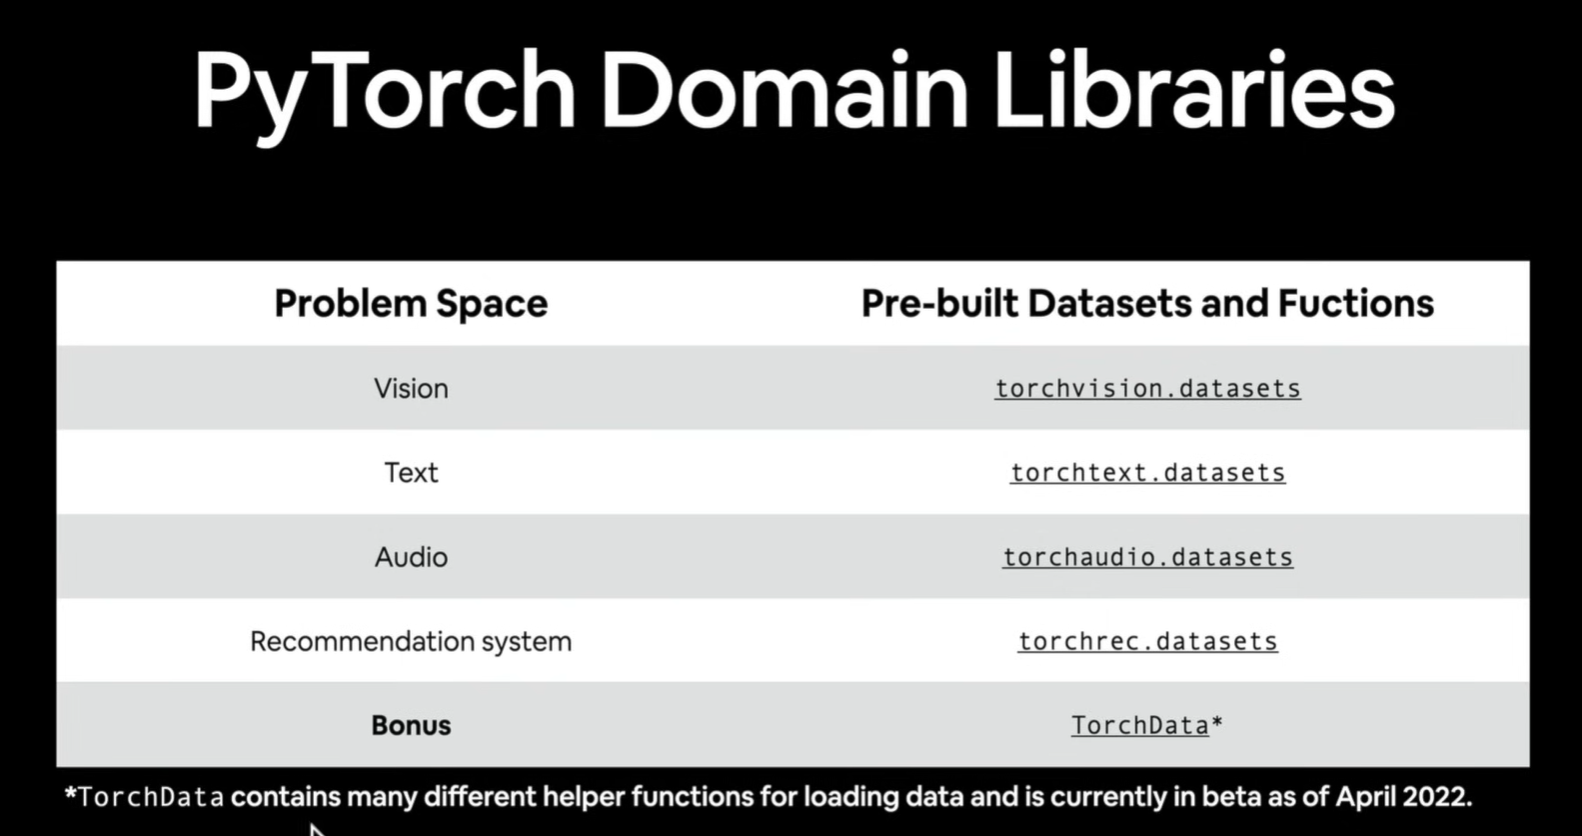

#4 Pytorch custom datsets
* How do you get your own data in to pytorch
* ONe of the method of using it is via : Custom datasets


### Domain Libraries:
* Depending on thxt audio vicdeo, we would want to look for pytorch domain libraries for existing data loading functions and customizable data loading function


In [ ]:
import torch
from torch import nn
import pandas as pd
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
##Get Data
import requests
import zipfile
from pathlib import Path

#setting up a path to the datafolder,
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

print(f"creating {image_path} directory as it DNE")
image_path.mkdir(parents=True, exist_ok=True)

#Downloading the




creating data/pizza_steak_sushi directory as it DNE


In [ ]:
import requests
import zipfile
from pathlib import Path




with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza steak sushi data")
    f.write(request.content)
#unzip the data

with zipfile.ZipFile (data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza steak and sushi data...")
  zip_ref.extractall(image_path)

Unzipping pizza steak and sushi data...


##2 Becoming one with the data



In [ ]:
import os

def walk_through_dir(dir_path):
  """ Walks throgh the path returning its contents
  """
  for dirpath , dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


In [ ]:
walk_through_dir(image_path)
#

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.


In [ ]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
##use the pillow and sleep LOL, use the
image_path

PosixPath('data/pizza_steak_sushi')

In [ ]:
#watching the images
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/sushi/748830.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1232045.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2574453.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1129338.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3737197.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/821108.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/169392.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/840444.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1571146.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2797464.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/773725.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2021685.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2323548.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2590819.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2019344.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/14046.jpg'),
 PosixPath('dat

data/pizza_steak_sushi/train/pizza/5764.jpg
pizza
height 384, width 512


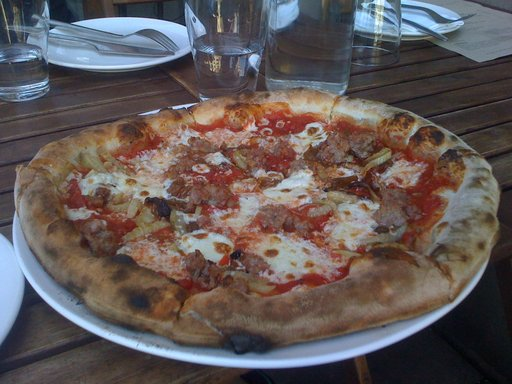

In [ ]:
#pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)
image_class = random_image_path.parent.stem
print(image_class)
img = Image.open(random_image_path)
print(f"height {img.height}, width {img.width}")
img

pizza


Text(0.5, 1.0, 'Image Class :pizza | image shape : (384, 512, 3)')

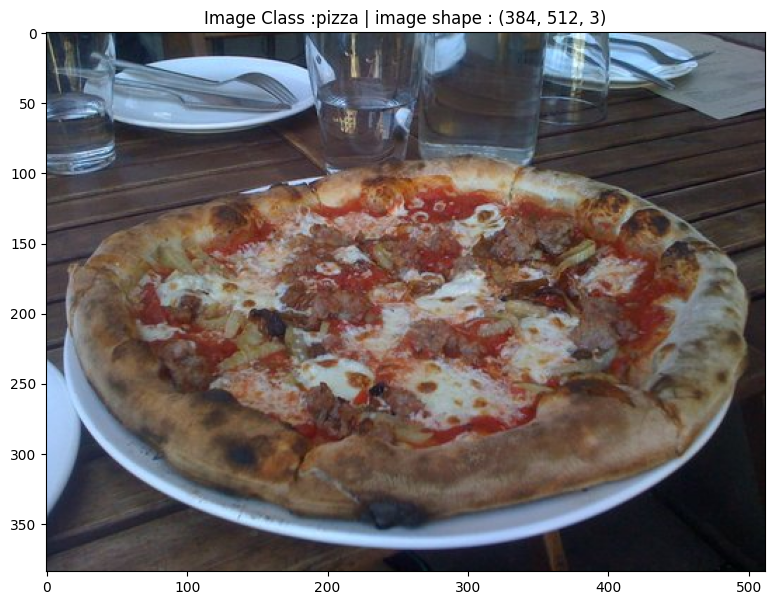

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Keep numpy import if other parts of the notebook rely on it, otherwise not strictly needed here if just calling imshow

# The 'img' variable is already a torch.Tensor as expected by the imshow helper.
# We will use the 'imshow' helper function defined in cell NJQJeIWIa3jm to properly display the image.
img_as_array = np.asarray(img)

img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))

plt.imshow(img_as_array)
plt.title(f"Image Class :{image_class} | image shape : {img_as_array.shape}")

array([[[ 91, 110, 106],
        [ 51,  70,  68],
        [ 41,  55,  56],
        ...,
        [ 87,  83,  97],
        [ 87,  83,  97],
        [ 85,  81,  95]],

       [[ 87, 103, 100],
        [ 84, 100,  97],
        [ 37,  51,  52],
        ...,
        [ 86,  84,  97],
        [ 86,  84,  97],
        [ 84,  82,  95]],

       [[ 76,  91,  86],
        [118, 133, 128],
        [ 39,  51,  51],
        ...,
        [ 87,  87,  99],
        [ 87,  87,  99],
        [ 85,  85,  97]],

       ...,

       [[ 64,  63,  71],
        [ 64,  63,  71],
        [ 65,  64,  72],
        ...,
        [  8,  12,  13],
        [  8,  12,  13],
        [  8,  12,  13]],

       [[ 67,  66,  74],
        [ 67,  66,  74],
        [ 67,  66,  74],
        ...,
        [  8,  12,  13],
        [  7,  11,  12],
        [  7,  11,  12]],

       [[ 65,  64,  72],
        [ 65,  64,  72],
        [ 67,  66,  74],
        ...,
        [  7,  11,  12],
        [  5,   9,  10],
        [  4,   8,   9]]], dtype=uint8)
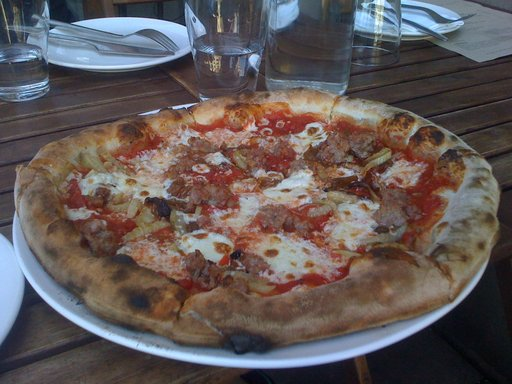

In [ ]:
img_as_array

#Image from the custom datasets in to tensor

* Before we can use our image data with pytoch
  * Turn the target data in to tensors
  * Turn it into a torch.utils.data.Dataset
  * Turn it into torch.utils.data.dataloader
  

In [251]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform = transforms.Compose([
    #Resize our images to 64, 64
    transforms.Resize(size = (64 ,64)),
    #flip the images randomly in horizontal axis
    transforms.RandomHorizontalFlip(p=0.5),
    #transform it into torch tensor
    transforms.ToTensor()
])




In [252]:
print(data_transform(img).shape,
data_transform(img).dtype)



torch.Size([3, 64, 64]) torch.float32


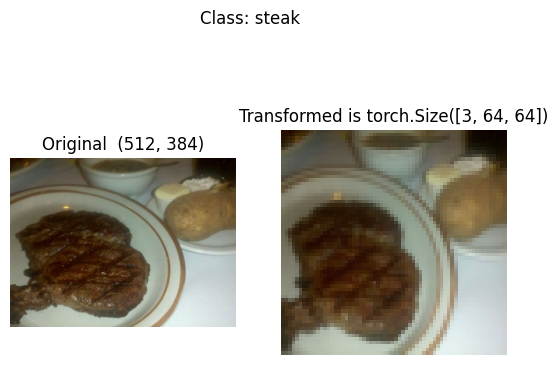

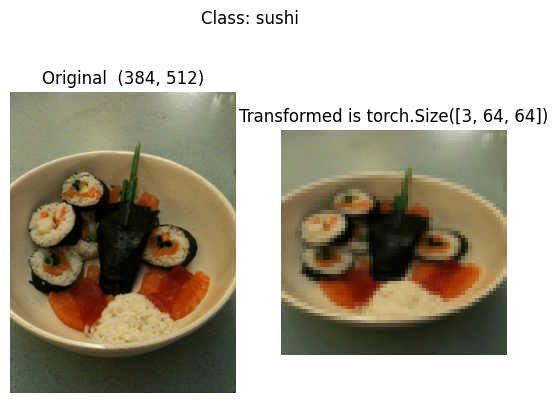

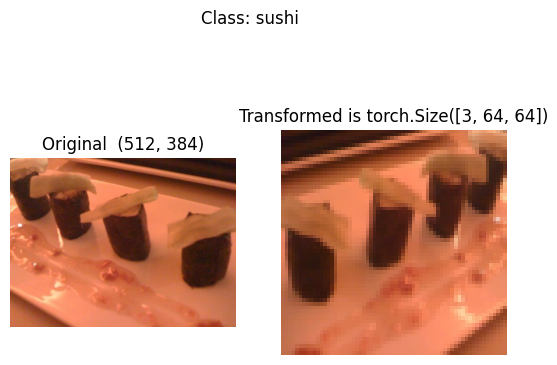

In [259]:
def plot_transformed_images(image_paths: list, transform, n =3, seed = None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k = n)
  for image in random_image_paths:
    with Image.open(image) as f:
      fig,ax = plt.subplots(nrows = 1, ncols =2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original  {f.size}")
      ax[0].axis(False)

      transformed_images = transform(f)
      ax[1].imshow(transformed_images.permute(1, 2, 0)) # Permute to (H, W, C) for matplotlib
      ax[1].set_title(f"Transformed is {transformed_images.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image.parent.stem}")

plot_transformed_images(image_paths = image_path_list, transform = data_transform, n =3, seed = None)